# Getting Started with Python: Exploratory Data Analysis (Polars)

**Author:** Alp Tezbasaran 
**Updated by:** Bhaskar Ray
**Last updated:** 2026-06-26 

This notebook is designed for a **live, in-person workshop**. It is intentionally iterative: we’ll ask a question, inspect the data, try a quick transformation or plot, then repeat.


## 0. Accessibility: theme, text size, and output

- **Tools → Settings → Theme**: Light / Dark / System
- **Tools → Settings → Editor → Font size**: increase if needed
- **Browser zoom**: Cmd/Ctrl `+` or `-`

Teaching tip: agree on a standard zoom level at the start.


## Learning outcomes

By the end of this workshop, you will be able to:

- Load tabular data into Polars
- Profile data (shape, schema, missingness, unique values)
- Use **expressions** to filter and create features
- Summarize with `group_by().agg()` and explain what information is lost
- Use pivoting as **“groupby + aggregation + reshaping”**
- Make quick univariate and bivariate plots for exploration
- Recognize when to use **lazy** execution for performance


## The EDA loop (a simple roadmap)

EDA is not linear. A useful loop is:

1. **Inventory**: What columns do we have? What types? How big?
2. **Quality**: Missing values, duplicates, weird values
3. **Univariate**: What does each variable look like by itself?
4. **Bivariate / multivariate**: What relationships appear?
5. **Feature ideas**: Create features that clarify relationships
6. **Summarize & communicate**: tables/plots + short written takeaways

```mermaid
flowchart LR
    A[Inventory] --> B[Quality]
    B --> C[Univariate]
    C --> D[Bivariate / multivariate]
    D --> E[Feature ideas]
    E --> F[Summarize & communicate]
    F --> A
```

We’ll follow that loop on a few small datasets.


## 1. Setup

We’ll use **Polars** for data work and **matplotlib** for plotting.

If you’re in Google Colab, install Polars once per session.


In [1]:
import polars as pl
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

data_dir = Path('data')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True

## Polars: the 3 practical pillars

Think of Polars as: **operation + expression + execution mode**.

This gives students a simple mental model:

1. **Operation (what you do)**
   - DataFrame/LazyFrame methods define the step: `select`, `filter`, `with_columns`, `group_by`, `join`.
2. **Expression (how you describe it)**
   - Expressions define the rule/math: `pl.col(...)`, `pl.when(...).then(...).otherwise(...)`, boolean logic, arithmetic.
3. **Execution mode (when/how it runs)**
   - Eager runs now.
   - Lazy builds a plan and runs at `collect()`, which helps Polars optimize.

```mermaid
flowchart LR
    A[Operation: select/filter/group_by] --> B[Expression: pl.col + rules]
    B --> C[Execution mode: eager or lazy]
```

### Easy analogy: cooking

- **Operation** = the cooking action (chop, mix, bake)
- **Expression** = the recipe rule ("add 2 cups", "if too salty, add water")
- **Execution mode** = when you cook
  - eager: cook each step immediately
  - lazy: plan the full recipe first, then cook efficiently

For today, we focus on the first two pillars most of the time.
We introduce lazy later as a performance bonus, not a required concept.


### Expression primer (5 minutes)

In Polars, you rarely write row-by-row loops. You write **column expressions**.

Common building blocks:
- `pl.col('x')` → refer to a column
- `.alias('new_name')` → rename an expression result
- Boolean logic: `&` (and), `|` (or), `~` (not)
- **Use parentheses** with boolean logic: `(cond1) & (cond2)`
- Conditional: `pl.when(cond).then(val).otherwise(val)`
- String/date helpers: `.str.*`, `.dt.*`


In [2]:
expr_demo = pl.DataFrame({'x':[1,2,3,None], 's':[' A ','b','b',None]})
(
    expr_demo
    .with_columns([
        pl.col('x').fill_null(0).alias('x_filled'),
        pl.col('s').str.to_lowercase().str.strip_chars().fill_null('missing').alias('s_clean'),
        pl.when(pl.col('x').is_null()).then(pl.lit('was_null')).otherwise(pl.lit('ok')).alias('flag')
    ])
)

x,s,x_filled,s_clean,flag
i64,str,i64,str,str
1,""" A """,1,"""a""","""ok"""
2,"""b""",2,"""b""","""ok"""
3,"""b""",3,"""b""","""ok"""
null,null,0,"""missing""","""was_null"""


## Checkpoint A (quick)

- Everyone can run the setup cell and the expression demo
- If you’re stuck on imports/paths, follow along and we’ll fix it during the next pause


## 2. Load datasets

We’ll use three small datasets:

- `NCSU_Mascots_v1.csv` *(synthetic)*
- `NCSU Celebrity Graduates_v1.csv` *(synthetic)*
- `penguins.csv` *(public dataset, light cleaning demo)*

Even with synthetic data, practice good habits: avoid re-identification and think about bias.


In [3]:
mascots = pl.read_csv(data_dir / 'NCSU_Mascots_v1.csv')
celebs = pl.read_csv(data_dir / 'NCSU Celebrity Graduates_v1.csv')
penguins_raw = pl.read_csv(data_dir / 'penguins.csv')

(mascots.shape, celebs.shape, penguins_raw.shape)

((50, 22), (100, 16), (344, 7))

## 3. Inventory & profiling

Start every EDA with:
- **shape** (rows, columns)
- **schema** (column types)
- **preview** (head/tail)

Then a quick profile:
- missingness (counts *and* rates)
- numeric summaries
- categorical cardinality (how many unique values?)
- duplicates (do we expect any?)


In [4]:
print('Mascots:', mascots.shape)
print(mascots.schema)
mascots.head(5)

Mascots: (50, 22)
Schema({'Name': String, 'Species': String, 'Breed': String, 'Prior Position': String, 'Prior Employer': String, 'Interview Date': String, 'Hire Year': Int64, 'Hire Date': String, 'Termination Year': Float64, 'Termination Date': String, 'Termination Reason': String, 'Post Employment Position': String, 'Nick Name': String, 'Temperment': String, 'Fur Color': String, 'Age': Float64, 'Height': Float64, 'Weight': String, 'Offer Sent': Int64, 'Starting Salary': Int64, 'Biter': Int64, 'Hired': Int64})


Name,Species,Breed,Prior Position,Prior Employer,Interview Date,Hire Year,Hire Date,Termination Year,Termination Date,Termination Reason,Post Employment Position,Nick Name,Temperment,Fur Color,Age,Height,Weight,Offer Sent,Starting Salary,Biter,Hired
str,str,str,str,str,str,i64,str,f64,str,str,str,str,str,str,f64,f64,str,i64,i64,i64,i64
"""Wallace Whitfield Riddick""","""Human""",null,null,null,"""1899-02-17""",1899,"""1899-02-23""",null,null,null,null,null,"""patient""","""cream""",5.0,34.5,"""40.0""",1,9481,0,1
"""Tige""","""Dog""","""English Bulldog""",null,null,"""1910-02-16""",1910,"""1910-02-17""",null,null,null,null,null,"""sweet""","""brown""",10.9,14.2,"""51.0""",1,10130,0,1
"""Togo""","""Dog""","""American Bulldog""",null,null,"""1910-06-28""",1910,"""1910-07-01""",null,null,null,null,null,"""sweet""","""brown""",10.4,24.4,"""90.0""",1,9572,0,1
"""State""","""Wolf""","""Timber Wolf""",null,null,"""1940-05-02""",1940,"""1940-05-03""",1946.0,"""1940-05-17""","""New Job""","""Traveling Zoo""",null,"""bewildered""","""multi-color""",9.8,29.8,"""112.5""",1,9921,0,1
"""Lobo I""","""Wolf""","""Timber Wolf""","""Zoo""","""Philadelphia Zoo""","""1959-08-26""",1959,"""1959-09-03""",1959.0,"""1959-05-29""","""Passed Away""",null,null,"""quiet""","""gray""",10.3,27.2,"""100.15""",1,9509,0,1


In [5]:
mascots.tail(5)

Name,Species,Breed,Prior Position,Prior Employer,Interview Date,Hire Year,Hire Date,Termination Year,Termination Date,Termination Reason,Post Employment Position,Nick Name,Temperment,Fur Color,Age,Height,Weight,Offer Sent,Starting Salary,Biter,Hired
str,str,str,str,str,str,i64,str,f64,str,str,str,str,str,str,f64,f64,str,i64,i64,i64,i64
"""Shadow""","""Spider""","""Golden Orb Weaver""","""Web Infrastructure Designer""","""Giggle ""","""2013-04-12""",null,null,null,null,null,null,"""Gizmo""","""devilishly clever""",null,11.4,4.0,"""0.009""",0,null,0,0
"""Clover""","""Rabbit""","""Mini Rex""","""Burrow Engineer""","""Hillside Civil Engineering""","""1952-07-30""",null,null,null,null,null,null,null,"""frightened""","""brown""",10.0,12.4,"""3.71""",0,null,0,0
"""Sophie""","""Rabbit""","""Holland Lop""","""Carrot Quality Control Associa…","""Publix""","""1953-11-17""",null,null,null,null,null,null,"""Spock""","""social""","""black""",9.7,10.55,"""3.18""",1,9904,0,0
"""Pixel""","""Turtle""","""Eastern Box""","""Rock Impersonator""","""No Moves, LLC""","""1997-08-25""",null,null,null,null,null,null,"""Gizmo""","""patient""",null,11.6,5.44,"""1.49""",0,null,0,0
"""Baron""","""Dog""","""Dalmatian""","""Firehouse Morale Officer""","""Raleigh Fire Department""","""1990-08-06""",null,null,null,null,null,null,null,"""social""","""black""",14.7,21.5,"""57.68""",0,null,0,0


In [6]:
print('Celebs:', celebs.shape)
print(celebs.schema)
celebs.head(5)

Celebs: (100, 16)
Schema({'#': Int64, 'Name': String, 'Birth Year': Int64, 'Death Year': Float64, 'Occupation(s)': String, 'Country Born In': String, 'Birthdate': String, 'Age': Int64, 'Graduation Month/Year': String, 'Workstudy Position': String, 'Workstudy Hourly Rate': Float64, 'GPA': Float64, 'College': String, 'Loved Library?': Int64, 'Favorite NCSU Hangout': String, 'Favorite Raleigh Hangout': String})


#,Name,Birth Year,Death Year,Occupation(s),Country Born In,Birthdate,Age,Graduation Month/Year,Workstudy Position,Workstudy Hourly Rate,GPA,College,Loved Library?,Favorite NCSU Hangout,Favorite Raleigh Hangout
i64,str,i64,f64,str,str,str,i64,str,str,f64,f64,str,i64,str,str
88,"""Adrian Wilson""",1979,null,"""American football player""","""United States""","""1979-10-12""",45,"""Dec/1997""","""IT""",15.52,3.88,"""Humanities and Social Sciences""",0,"""Library""","""Cup A Joe"""
95,"""Ahmet Özal""",1955,null,"""businessperson, politician""","""Turkey""","""1955-09-05""",69,"""Dec/1974""","""Campus Events""",16.44,3.54,"""Education""",0,"""Fountain Dining Hall""","""The Optimist"""
72,"""Akihiro Kitamura""",1979,null,"""seiyū, actor, television actor""","""Japan""","""1979-03-25""",45,"""Dec/1997""","""IT""",16.89,2.17,"""Natural Resources""",0,"""Free Expression Tunnel""","""The Optimist"""
10,"""Anna Camp""",1982,null,"""film actor, television actor, …","""United States""","""1982-09-27""",42,"""Dec/2000""","""Campus Events""",14.84,2.18,"""Veterinary Medicine""",0,"""Fountain Dining Hall""","""Mitch's Tavern"""
5,"""Anthony Mackie""",1978,null,"""stage actor, film actor, telev…","""United States""","""1978-09-23""",46,"""Dec/1996""","""Library""",17.79,3.55,"""Textiles""",0,"""The Brickyard""","""State Farmers Market Restauran…"


In [7]:
celebs.tail(5)

#,Name,Birth Year,Death Year,Occupation(s),Country Born In,Birthdate,Age,Graduation Month/Year,Workstudy Position,Workstudy Hourly Rate,GPA,College,Loved Library?,Favorite NCSU Hangout,Favorite Raleigh Hangout
i64,str,i64,f64,str,str,str,i64,str,str,f64,f64,str,i64,str,str
70,"""Vinny Del Negro""",1966,null,"""basketball player, basketball …","""United States""","""1966-08-09""",58,"""Dec/1984""","""Dining""",15.9,3.49,"""Sciences""",1,"""The Brickyard""","""Jubala Coffee"""
69,"""Vivian Howard""",1978,null,"""restaurateur, cook""",null,"""1978-03-18""",46,"""Dec/1996""","""Dining""",17.22,3.37,"""Humanities and Social Sciences""",0,"""The Brickyard""","""Raleigh Beer Garden"""
90,"""Walter B. Jones""",1943,2019.0,"""politician""","""United States""","""1943-02-10""",81,"""Dec/1962""","""Campus Events""",17.43,3.46,"""Design""",0,"""Reynolds Coliseum""","""Irish Coffee Lab"""
65,"""Yasonna Laoly""",1953,null,"""politician, political candidat…","""Indonesia""","""1953-05-27""",71,"""Dec/1972""","""Theater""",16.89,2.57,"""Natural Resources""",0,"""Free Expression Tunnel""","""Boxcar"""
6,"""Zach Galifianakis""",1969,null,"""voice actor, screen writer, fi…","""United States""","""1969-10-01""",55,"""May/1987""","""Dining""",14.24,2.42,"""Design""",1,"""The Brickyard""","""The Optimist"""


In [8]:
print('Penguins:', penguins_raw.shape)
print(penguins_raw.schema)
penguins_raw.head(5)

Penguins: (344, 7)
Schema({'species': String, 'island': String, 'bill_length_mm': Float64, 'bill_depth_mm': Float64, 'flipper_length_mm': Int64, 'body_mass_g': Int64, 'sex': String})


species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
str,str,f64,f64,i64,i64,str
"""Adelie""","""Torgersen""",39.1,18.7,181,3750,"""MALE"""
"""Adelie""","""Torgersen""",39.5,17.4,186,3800,"""FEMALE"""
"""Adelie""","""Torgersen""",40.3,18.0,195,3250,"""FEMALE"""
"""Adelie""","""Torgersen""",null,null,null,null,null
"""Adelie""","""Torgersen""",36.7,19.3,193,3450,"""FEMALE"""


In [9]:
penguins_raw.tail(5)

species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
str,str,f64,f64,i64,i64,str
"""Gentoo""","""Biscoe""",null,null,null,null,null
"""Gentoo""","""Biscoe""",46.8,14.3,215,4850,"""FEMALE"""
"""Gentoo""","""Biscoe""",50.4,15.7,222,5750,"""MALE"""
"""Gentoo""","""Biscoe""",45.2,14.8,212,5200,"""FEMALE"""
"""Gentoo""","""Biscoe""",49.9,16.1,213,5400,"""MALE"""


### Missingness: counts and rates

`null_count()` gives counts. For teaching and comparison across tables, rates (percent) are often easier to interpret.


In [10]:
n = mascots.height

mascots_missingness = (
    mascots
    .null_count()
    .transpose(include_header=True, header_name='column', column_names=['null_count'])
    .with_columns([
        (pl.col('null_count') / pl.lit(n)).alias('null_rate'),
        (pl.col('null_count') / pl.lit(n) * 100).alias('null_pct'),
    ])
    .sort('null_count', descending=True)
)

mascots_missingness.head(12)

column,null_count,null_rate,null_pct
str,u32,f64,f64
"""Post Employment Position""",47,0.94,94.0
"""Termination Year""",46,0.92,92.0
"""Termination Date""",46,0.92,92.0
"""Termination Reason""",43,0.86,86.0
"""Hire Year""",38,0.76,76.0
…,…,…,…
"""Nick Name""",29,0.58,58.0
"""Fur Color""",17,0.34,34.0
"""Prior Position""",9,0.18,18.0


### Quick numeric summary

This is triage, not a final report.


In [11]:
mascots.describe()

statistic,Name,Species,Breed,Prior Position,Prior Employer,Interview Date,Hire Year,Hire Date,Termination Year,Termination Date,Termination Reason,Post Employment Position,Nick Name,Temperment,Fur Color,Age,Height,Weight,Offer Sent,Starting Salary,Biter,Hired
str,str,str,str,str,str,str,f64,str,f64,str,str,str,str,str,str,f64,f64,str,f64,f64,f64,f64
"""count""","""50""","""50""","""49""","""41""","""41""","""50""",12.0,"""12""",4.0,"""4""","""7""","""3""","""21""","""49""","""33""",50.0,50.0,"""50""",50.0,17.0,50.0,50.0
"""null_count""","""0""","""0""","""1""","""9""","""9""","""0""",38.0,"""38""",46.0,"""46""","""43""","""47""","""29""","""1""","""17""",0.0,0.0,"""0""",0.0,33.0,0.0,0.0
"""mean""",null,null,null,null,null,null,1964.25,null,1973.75,null,null,null,null,null,null,10.324,19.284,null,0.34,9862.764706,0.08,0.24
"""std""",null,null,null,null,null,null,43.587164,null,32.356092,null,null,null,null,null,null,1.916263,16.461679,null,0.478518,356.507807,0.274048,0.431419
"""min""","""Ash""","""Alpaca""","""African Grey Parrot""",""" Demolition Expert""","""ACME Food Storage""","""1899-02-17""",1899.0,"""1899-02-23""",1946.0,"""1940-05-17""","""Escaped""","""Art Thief""","""Boo Boo""","""bewildered""","""black""",5.0,1.25,"""0.0003""",0.0,9313.0,0.0,0.0
"""25%""",null,null,null,null,null,null,1940.0,null,1959.0,null,null,null,null,null,null,9.1,7.59,null,0.0,9572.0,0.0,0.0
"""50%""",null,null,null,null,null,null,1966.0,null,1970.0,null,null,null,null,null,null,10.3,13.25,null,0.0,9904.0,0.0,0.0
"""75%""",null,null,null,null,null,null,2010.0,null,1970.0,null,null,null,null,null,null,11.6,26.2,null,1.0,10086.0,0.0,0.0
"""max""","""Willow""","""Wolf""","""Wolf/German Shepard""","""Zoo""","""Walmart""","""2024-09-09""",2021.0,"""2021-11-17""",2020.0,"""2020-11-09""","""Retired""","""Traveling Zoo""","""Yoda""","""sweet""","""white""",14.7,77.34,"""90.0""",1.0,10478.0,1.0,1.0


### Categorical “shape” (unique counts)

This is a fast way to find columns with many categories (IDs, free text, etc.).


In [12]:
(
    mascots
    .select(pl.all().n_unique())
    .transpose(include_header=True, header_name='column', column_names=['n_unique'])
    .sort('n_unique', descending=True)
)

column,n_unique
str,u32
"""Name""",50
"""Interview Date""",50
"""Weight""",50
"""Height""",49
"""Breed""",45
…,…
"""Termination Date""",5
"""Post Employment Position""",4
"""Offer Sent""",2


### Duplicates (quick check)

First ask: **do we expect duplicates?** If not, check for them.

Note: “duplicate” depends on *which columns* define identity.


In [13]:
mascots.select([
    pl.len().alias('n_rows'),
    pl.struct(pl.all()).is_duplicated().sum().alias('n_duplicate_rows')
])

n_rows,n_duplicate_rows
u32,u32
50,0


### Try it yourself (profiling)

- **Minimum**: show the 10 columns with the highest `null_count` in `mascots`.
- **Stretch**: show the 10 columns with the highest `null_pct`.

Expected result shape: a table with columns like `column`, `null_count`, `null_rate`, `null_pct`.


In [14]:
(
    mascots
    .null_count()
    .transpose(include_header=True, header_name='column', column_names=['null_count'])
    .with_columns([
        (pl.col('null_count') / pl.lit(mascots.height)).alias('null_rate'),
        (pl.col('null_count') / pl.lit(mascots.height) * 100).alias('null_pct'),
    ])
    .sort('null_count', descending=True)
    .head(10)
)

column,null_count,null_rate,null_pct
str,u32,f64,f64
"""Post Employment Position""",47,0.94,94.0
"""Termination Year""",46,0.92,92.0
"""Termination Date""",46,0.92,92.0
"""Termination Reason""",43,0.86,86.0
"""Hire Year""",38,0.76,76.0
"""Hire Date""",38,0.76,76.0
"""Starting Salary""",33,0.66,66.0
"""Nick Name""",29,0.58,58.0
"""Fur Color""",17,0.34,34.0


## Checkpoint B

You should now have a reusable profiling checklist: shape, schema, preview, missingness (counts/rates), `describe`, `n_unique`, and “do we expect duplicates?”.


## 4. Univariate exploration

Univariate exploration answers: **“What does this variable look like by itself?”**

- Numeric: distribution (histogram), outliers (boxplot)
- Categorical: counts (bar chart)

We’ll do a quick categorical count on `mascots` and a histogram on `celebs` GPA.


In [15]:
species_counts = (
    mascots
    .group_by('Species')
    .len()
    .sort('len', descending=True)
)
species_counts

Species,len
str,u32
"""Dog""",10
"""Cat""",5
"""Bird""",4
"""Rabbit""",3
"""Horse""",3
…,…
"""Hedgehog""",1
"""Mouse""",1
"""Duck""",1


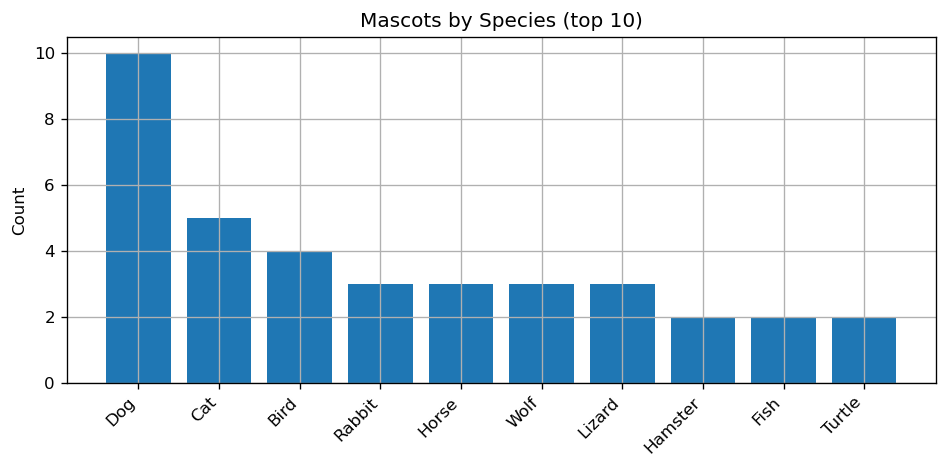

In [16]:
top_n = 10
top_species = species_counts.head(top_n)

plt.figure(figsize=(8, 4))
plt.bar(top_species['Species'].to_list(), top_species['len'].to_list())
plt.xticks(rotation=45, ha='right')
plt.ylabel('Count')
plt.title(f'Mascots by Species (top {top_n})')
plt.tight_layout()
plt.show()

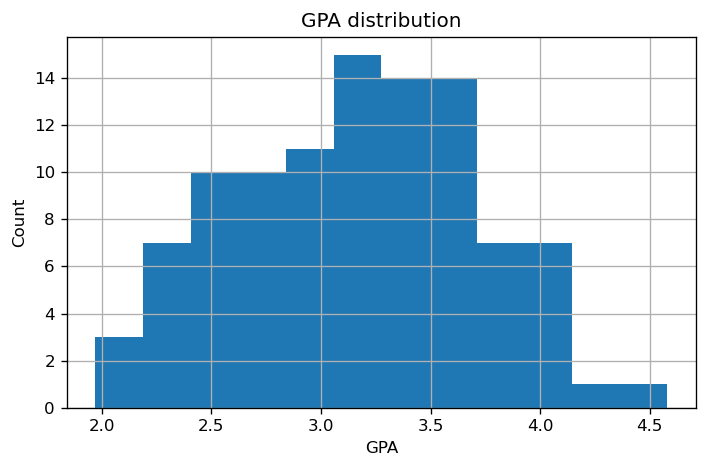

In [17]:
celebs_typed = celebs.with_columns([
    pl.col('GPA').cast(pl.Float64),
    pl.col('Workstudy Hourly Rate').cast(pl.Float64),
    pl.col('Loved Library?').cast(pl.Int64),
])


gpa = celebs_typed['GPA'].drop_nulls().to_list()
plt.figure(figsize=(6,4))
plt.hist(gpa, bins=12)
plt.xlabel('GPA')
plt.ylabel('Count')
plt.title('GPA distribution')
plt.tight_layout()
plt.show()

### Try it yourself (univariate)

Make a bar chart of **counts by College** in the celebs dataset.

- **Minimum**: produce the `college_counts` table.
- **Stretch**: make the bar chart; optionally plot only the top 10.

<details>
<summary>Solution</summary>

```python
college_counts = celebs.group_by('College').len().sort('len', descending=True)

top_n = 10
to_plot = college_counts.head(top_n)

plt.figure(figsize=(8,4))
plt.bar(to_plot['College'].to_list(), to_plot['len'].to_list())
plt.xticks(rotation=45, ha='right')
plt.ylabel('Count')
plt.title(f'Celebs by College (top {top_n})')
plt.tight_layout()
plt.show()
```

</details>


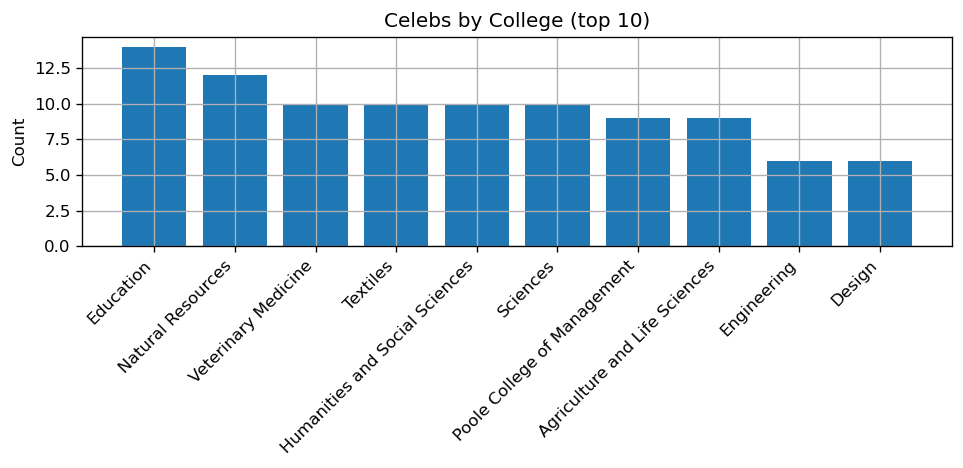

In [18]:
college_counts = celebs.group_by('College').len().sort('len', descending=True)


top_n = 10
to_plot = college_counts.head(top_n)

plt.figure(figsize=(8,4))
plt.bar(to_plot['College'].to_list(), to_plot['len'].to_list())
plt.xticks(rotation=45, ha='right')
plt.ylabel('Count')
plt.title(f'Celebs by College (top {top_n})')
plt.tight_layout()
plt.show()

## 5. Cleaning + feature creation (Penguins)

Cleaning is easiest when it’s tied to a question.

Here we’ll:
- standardize the `sex` column
- drop rows missing key measurements (for a specific analysis)
- create a feature (`bill_ratio`) **before** we summarize

Note: dropping rows is not always appropriate; it depends on your goal.


In [19]:
penguins = (
    penguins_raw
    .with_columns(
        pl.col('sex')
          .str.to_lowercase()
          .str.strip_chars()
          .alias('sex')
    )
    .with_columns(
        pl.when(pl.col('sex').is_null())
          .then(pl.lit('unknown'))
          .otherwise(pl.col('sex'))
          .alias('sex')
    )
)

(
    penguins
    .null_count()
    .transpose(include_header=True, header_name='column', column_names=['null_count'])
    .with_columns([
        (pl.col('null_count') / pl.lit(penguins.height)).alias('null_rate'),
        (pl.col('null_count') / pl.lit(penguins.height) * 100).alias('null_pct'),
    ])
    .sort('null_count', descending=True)
    .head(12)
)

column,null_count,null_rate,null_pct
str,u32,f64,f64
"""bill_length_mm""",2,0.005814,0.581395
"""bill_depth_mm""",2,0.005814,0.581395
"""flipper_length_mm""",2,0.005814,0.581395
"""body_mass_g""",2,0.005814,0.581395
"""species""",0,0.0,0.0
"""island""",0,0.0,0.0
"""sex""",0,0.0,0.0


In [20]:
penguins_clean = penguins.drop_nulls(
    subset=['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g']
).with_columns(
    (pl.col('bill_length_mm') / pl.col('bill_depth_mm')).alias('bill_ratio')
)

penguins_clean.head(5)

species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,bill_ratio
str,str,f64,f64,i64,i64,str,f64
"""Adelie""","""Torgersen""",39.1,18.7,181,3750,"""male""",2.090909
"""Adelie""","""Torgersen""",39.5,17.4,186,3800,"""female""",2.270115
"""Adelie""","""Torgersen""",40.3,18.0,195,3250,"""female""",2.238889
"""Adelie""","""Torgersen""",36.7,19.3,193,3450,"""female""",1.901554
"""Adelie""","""Torgersen""",39.3,20.6,190,3650,"""male""",1.907767


### Sanity check distributions (univariate, after cleaning)

A quick plot helps confirm we didn’t do something surprising.


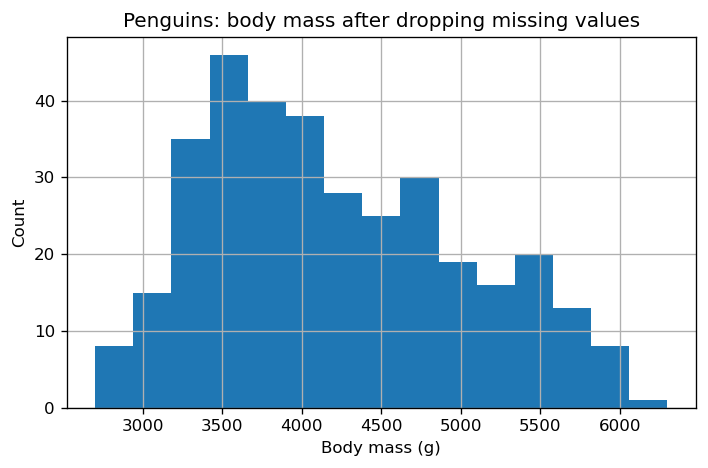

In [21]:
mass = penguins_clean['body_mass_g'].to_list()
plt.figure(figsize=(6,4))
plt.hist(mass, bins=15)
plt.xlabel('Body mass (g)')
plt.ylabel('Count')
plt.title('Penguins: body mass after dropping missing values')
plt.tight_layout()
plt.show()

## 6. Bivariate exploration

Bivariate exploration asks: **“How do two variables relate?”**

Common patterns:
- numeric ↔ numeric: scatter plot, correlation
- category ↔ numeric: boxplot, group summaries


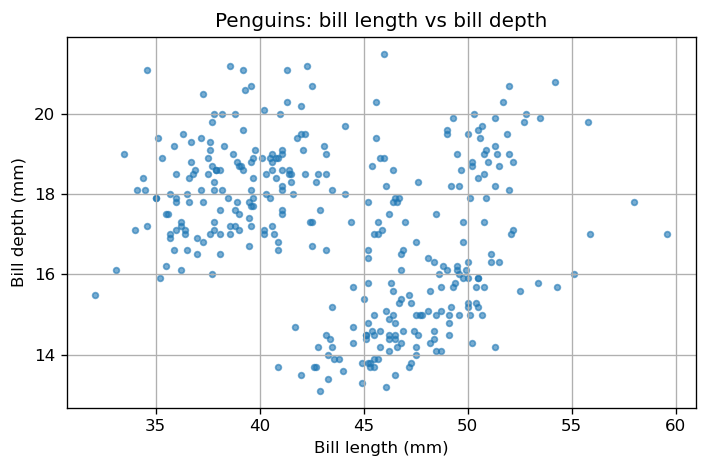

In [22]:
x = penguins_clean['bill_length_mm'].to_list()
y = penguins_clean['bill_depth_mm'].to_list()

plt.figure(figsize=(6,4))
plt.scatter(x, y, s=12, alpha=0.6)
plt.xlabel('Bill length (mm)')
plt.ylabel('Bill depth (mm)')
plt.title('Penguins: bill length vs bill depth')
plt.tight_layout()
plt.show()

In [23]:
penguins_clean.select([
    pl.corr('bill_length_mm', 'bill_depth_mm').alias('corr_bill_len_depth'),
    pl.corr('flipper_length_mm', 'body_mass_g').alias('corr_flipper_mass'),
])

corr_bill_len_depth,corr_flipper_mass
f64,f64
-0.235053,0.871202


### Grouped Exploration

Plotting bill depth against bill length for all penguins combined suggests that penguins with longer bill lengths have smaller depths. This observation matches the negative correlation between bill length and bill depth above.
- **Something suspicious?** What are those clusters of points and what do they represent?
- **Are we missing something?** Look for other variables that may be interfering with (confounding) the trend.

Some simple techniques to involve a third variable in a bivariate plot are:
- **Color:** The most common technique used for both discrete and continuous variables.
- **Shape:** Common, but less used due to limitation in choices and distinguishability. Suitable for discrete variables only.
- **Size:** Less common, niche specific. Usually used for continuous variables.
- **Faceting** *(advanced)***:** Splits the plot into separate panels, one per group. Cleaner than overlaying for many or heavily overlapping groups. Suitable for discrete variables only.

Let's color the points by **"species"** and re-examine the trend.

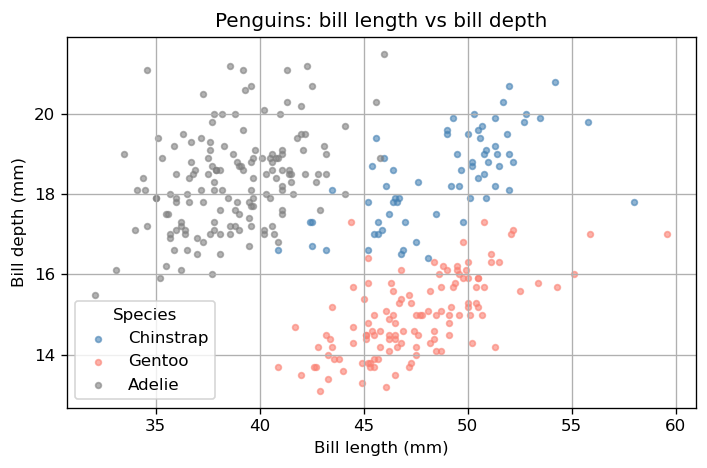

In [24]:
x = penguins_clean['bill_length_mm'].to_list()
y = penguins_clean['bill_depth_mm'].to_list()

colors = {'Chinstrap': 'steelblue', 'Gentoo': 'salmon', 'Adelie': 'grey'}
species_col = penguins_clean['species'].to_list()

plt.figure(figsize=(6,4))
for species, color in colors.items():
    mask = [s == species for s in species_col]
    plt.scatter([v for v, m in zip(x, mask) if m],
                [v for v, m in zip(y, mask) if m],
                s=12, alpha=0.6, color=color, label=species)
plt.xlabel('Bill length (mm)')
plt.ylabel('Bill depth (mm)')
plt.title('Penguins: bill length vs bill depth')
plt.legend(title='Species')
plt.tight_layout()
plt.show()

The relationship between bill length and bill depth now look positive within each species. This is a classic example of **Simpson's Paradox**. Let's now check out the correlations by species.

In [25]:
penguins_clean.group_by('species').agg([
    pl.corr('bill_length_mm', 'bill_depth_mm').alias('corr_bill_len_depth'),
    pl.corr('flipper_length_mm', 'body_mass_g').alias('corr_flipper_mass'),
])

species,corr_bill_len_depth,corr_flipper_mass
str,f64,f64
"""Chinstrap""",0.653536,0.641559
"""Gentoo""",0.643384,0.702667
"""Adelie""",0.391492,0.468202


The correlations corroborate our observations. Are there other patterns we are yet to uncover? Let's use different shapes to label the sexes.

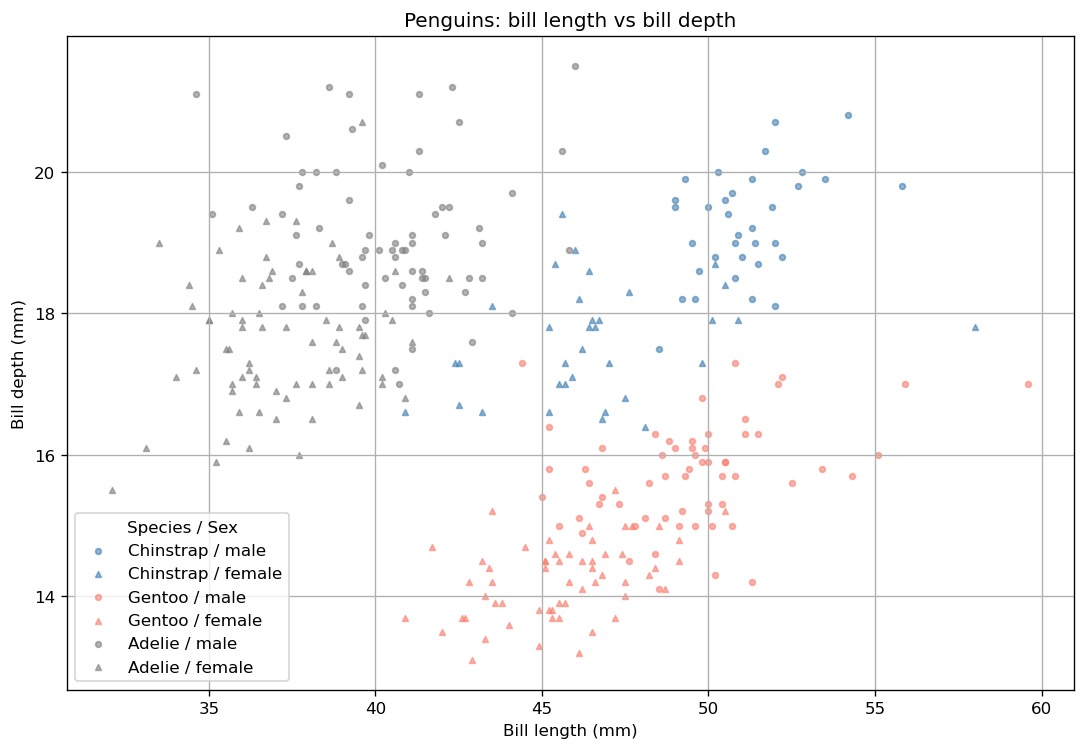

In [26]:
markers = {'male': 'o', 'female': '^'}
sex_col = penguins_clean['sex'].to_list()

plt.figure(figsize=(6,4))
for species, color in colors.items():
    for sex, marker in markers.items():
        mask = [s == species and g == sex for s, g in zip(species_col, sex_col)]
        plt.scatter([v for v, m in zip(x, mask) if m],
                    [v for v, m in zip(y, mask) if m],
                    s=12, alpha=0.6, color=color, marker=marker, label=f'{species} / {sex}')
plt.xlabel('Bill length (mm)')
plt.ylabel('Bill depth (mm)')
plt.title('Penguins: bill length vs bill depth')
plt.legend(title = 'Species / Sex', loc = 'best')
plt.tight_layout()
plt.subplots_adjust(right=1.5, top=1.5)
plt.show()

Within each species, females usually have shorter bill lengths and shallower bill depths than males.

In [27]:
mass_by_species = (
    penguins_clean
    .group_by('species')
    .agg([
        pl.len().alias('n'),
        pl.col('body_mass_g').mean().alias('mean_mass'),
        pl.col('body_mass_g').median().alias('median_mass'),
        pl.col('body_mass_g').quantile(0.9).alias('p90_mass'),
    ])
    .sort('mean_mass', descending=True)
)
mass_by_species

species,n,mean_mass,median_mass,p90_mass
str,u32,f64,f64,f64
"""Gentoo""",123,5076.01626,5000.0,5700.0
"""Chinstrap""",68,3733.088235,3700.0,4150.0
"""Adelie""",151,3700.662252,3700.0,4300.0


### Try it yourself (bivariate)

1) Filter penguins to a single island and compute mean body mass.  
2) Make a scatter plot of flipper length vs body mass.

- **Minimum**: island filter + mean body mass.
- **Stretch**: scatter plot; try `alpha=0.5` and a smaller `s` if it’s dense.

<details>
<summary>Hint</summary>
Use `.filter(pl.col('island') == 'Biscoe')` and `plt.scatter(...)`.
</details>


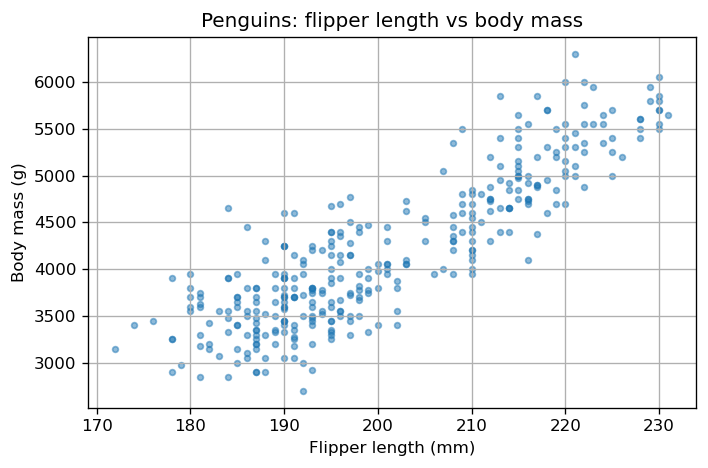

In [28]:
biscoe_mean_mass = (
    penguins_clean
    .filter(pl.col('island') == 'Biscoe')
    .select(pl.col('body_mass_g').mean().alias('mean_body_mass_g'))
)
biscoe_mean_mass

x = penguins_clean['flipper_length_mm'].to_list()
y = penguins_clean['body_mass_g'].to_list()

plt.figure(figsize=(6,4))
plt.scatter(x, y, s=12, alpha=0.5)
plt.xlabel('Flipper length (mm)')
plt.ylabel('Body mass (g)')
plt.title('Penguins: flipper length vs body mass')
plt.tight_layout()
plt.show()

## 7. Grouping + aggregation: choosing the grain

**Grouping** decides what one row in your output represents.

- `group_by(keys)` partitions rows into groups
- `.agg(...)` collapses each group (**information is lost**)

```mermaid
flowchart LR
    A[Row-level data] --> B[group_by keys]
    B --> C[agg summaries]
    C --> D[Fewer rows, more condensed meaning]
```

Rule of thumb: do row-level feature creation first, then group/aggregate last.


In [29]:
summary = (
    celebs_typed
    .group_by(['College', 'Workstudy Position'])
    .agg([
        pl.len().alias('n'),
        pl.col('GPA').mean().alias('gpa_mean'),
        pl.col('GPA').median().alias('gpa_median'),
        pl.col('Workstudy Hourly Rate').mean().alias('rate_mean'),
    ])
    .sort(['College','n'], descending=[False, True])
)
summary.head(10)

College,Workstudy Position,n,gpa_mean,gpa_median,rate_mean
str,str,u32,f64,f64,f64
"""Agriculture and Life Sciences""","""IT""",5,2.768,2.73,16.054
"""Agriculture and Life Sciences""","""Dining""",2,3.21,3.21,15.15
"""Agriculture and Life Sciences""","""Theater""",1,3.32,3.32,17.18
"""Agriculture and Life Sciences""","""Campus Events""",1,3.38,3.38,14.52
"""Design""","""Campus Events""",2,3.215,3.215,18.35
"""Design""","""IT""",2,3.685,3.685,16.78
"""Design""","""Dining""",1,2.42,2.42,14.24
"""Design""","""Library""",1,2.64,2.64,16.97
"""Education""","""IT""",3,3.723333,3.63,16.24


### Window functions: group-aware summaries without losing rows

Sometimes you want group context **but you don’t want to collapse rows**.

Window functions use `.over(group_keys)`.

Mental model: **groupby + join back**, but simpler.


In [30]:
celebs_with_context = (
    celebs_typed
    .with_columns([
        pl.col('GPA').mean().over('College').alias('college_gpa_mean'),
        (pl.col('GPA') - pl.col('GPA').mean().over('College')).alias('gpa_minus_college_mean'),
    ])
)
celebs_with_context.select(['Name','College','GPA','college_gpa_mean','gpa_minus_college_mean']).head(8)

Name,College,GPA,college_gpa_mean,gpa_minus_college_mean
str,str,f64,f64,f64
"""Adrian Wilson""","""Humanities and Social Sciences""",3.88,3.539,0.341
"""Ahmet Özal""","""Education""",3.54,3.462143,0.077857
"""Akihiro Kitamura""","""Natural Resources""",2.17,2.91,-0.74
"""Anna Camp""","""Veterinary Medicine""",2.18,2.677,-0.497
"""Anthony Mackie""","""Textiles""",3.55,3.249,0.301
"""Archie Miller""","""Design""",2.64,3.143333,-0.503333
"""Berlinda Tolbert""","""Agriculture and Life Sciences""",3.27,2.995556,0.274444
"""Bill Cowher""","""Natural Resources""",3.08,2.91,0.17


## 8. (OPTIONAL) Pivoting = groupby + aggregation + reshaping

A pivot table answers: **“Which values should become columns?”**

A pivot needs *one value per cell*. If multiple rows map to the same cell, you must choose an aggregation.

Here we pivot average GPA by College (rows) and Workstudy Position (columns).


In [31]:
pivot_gpa = celebs_typed.pivot(
    values='GPA',
    index='College',
    on='Workstudy Position',
    aggregate_function='mean'
)
pivot_gpa

College,IT,Campus Events,Library,Dining,AV Assistant,Theater
str,f64,f64,f64,f64,f64,f64
"""Humanities and Social Sciences""",3.675,2.79,3.75,3.42,null,3.91
"""Education""",3.723333,3.326667,3.516667,3.5,3.16,3.305
"""Natural Resources""",2.7825,2.47,3.61,3.19,null,2.475
"""Veterinary Medicine""",2.365,2.33,2.725,2.893333,3.25,null
"""Textiles""",2.77,3.29,3.55,3.636667,2.88,null
…,…,…,…,…,…,…
"""Agriculture and Life Sciences""",2.768,3.38,null,3.21,null,3.32
"""Poole College of Management""",2.903333,null,3.74,3.45,3.72,2.88
"""Engineering""",3.06,2.74,3.19,3.406667,null,null


### (OPTIONAL) Try it yourself (pivot)

Create a pivot of **mean hourly rate** by `College` (rows) and `Workstudy Position` (columns).

<details>
<summary>Solution</summary>

```python
celebs_typed.pivot(
    values='Workstudy Hourly Rate',
    index='College',
    on='Workstudy Position',
    aggregate_function='mean'
)
```

</details>


In [32]:
celebs_typed.pivot(
    values='Workstudy Hourly Rate',
    index='College',
    on='Workstudy Position',
    aggregate_function='mean'
)

College,IT,Campus Events,Library,Dining,AV Assistant,Theater
str,f64,f64,f64,f64,f64,f64
"""Humanities and Social Sciences""",16.04,17.24,15.78,16.5125,null,14.72
"""Education""",16.24,16.713333,14.916667,13.975,16.87,17.84
"""Natural Resources""",17.0925,14.76,17.01,16.255,null,16.665
"""Veterinary Medicine""",16.435,15.355,14.935,15.39,16.96,null
"""Textiles""",16.116667,16.3,19.29,16.506667,16.1,null
…,…,…,…,…,…,…
"""Agriculture and Life Sciences""",16.054,14.52,null,15.15,null,17.18
"""Poole College of Management""",15.826667,null,16.54,17.75,15.99,14.925
"""Engineering""",16.52,16.05,16.48,17.283333,null,null


## 9. (OPTIONAL) Joins (combining tables)

Joins combine columns from two tables using keys.

In real projects, joins often introduce missingness (unmatched keys) — so always inspect results.

Below is a tiny, self-contained example (not tied to the workshop datasets).


In [33]:
left = pl.DataFrame({'id':[1,2,3], 'x':[10,20,30]})
right = pl.DataFrame({'id':[2,3,4], 'y':['a','b','c']})

left.join(right, on='id', how='left')

id,x,y
i64,i64,str
1,10,null
2,20,"""a"""
3,30,"""b"""


## 10. (OPTIONAL) Lazy execution + query plans

Use lazy mode when:
- files are large
- you want to push filters into the scan
- you want Polars to optimize the whole query

```mermaid
flowchart LR
    A[scan_*] --> B[build lazy plan]
    B --> C[explain]
    C --> D[collect]
    D --> E[result DataFrame]
```

Key idea: `scan_*` builds a plan; `collect()` executes.


In [34]:
lazy_plan = (
    pl.scan_csv(data_dir / 'NCSU_Mascots_v1.csv')
      .filter(pl.col('Species').is_not_null())
      .group_by('Species')
      .agg(pl.len().alias('n'))
      .sort('n', descending=True)
)

lazy_plan  # shows a LazyFrame (a plan)

In [35]:
lazy_plan.explain()

'SORT BY [descending: [true]] [col("n")]\n  AGGREGATE[maintain_order: false]\n    [len().alias("n")] BY [col("Species")]\n    FROM\n    Csv SCAN [data/NCSU_Mascots_v1.csv]\n    PROJECT 1/22 COLUMNS\n    SELECTION: col("Species").is_not_null()\n    ESTIMATED ROWS: 59'

In [36]:
lazy_plan.collect().head(10)

Species,n
str,u32
"""Dog""",10
"""Cat""",5
"""Bird""",4
"""Wolf""",3
"""Lizard""",3
"""Horse""",3
"""Rabbit""",3
"""Turtle""",2
"""Hamster""",2


## 11. (OPTIONAL) Polars native plotting

Polars also supports native plotting via `DataFrame.plot` / `Series.plot` (Altair backend).

This is useful when you want a quick chart directly from a Polars table without writing matplotlib code.

If `altair` is not installed in your environment, skip this section.


In [43]:
try:
    import altair as alt
except ImportError:
    print("Optional section skipped: install altair to use Polars native plotting.")
else:
    species_counts = (
        mascots
        .group_by('Species')
        .len()
        .sort('len', descending=True)
        .head(10)
    )

    barplot_mascot = species_counts.plot.bar(
        x='Species',
        y='len'
    ).properties(title='Top mascot species (Polars native plot)')
    
    barplot_mascot.show()


alt.Chart(...)

## Wrap-up

What you practiced:

- Profiling: shape, schema, preview, missingness (counts + rates), unique counts, duplicates
- Univariate + bivariate exploration with quick plots
- Cleaning + feature creation **before** aggregation
- `group_by().agg()` summaries (lossy)
- Window functions (group context without collapsing)
- Optional: pivoting, joins, and lazy execution

Before you leave: write down **3 findings** and **1 next step**.
